# Milestone 2


In [2]:
# Core
import numpy as np
import pandas as pd
import re

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

# Imputation
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Pipeline & Model Selection
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV

# Resampling
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

NULLS_THRESHOLD = 0.6
CARDINALITY_THRESHOLD = 15
CORRELATION_THRESHOLD = 0.9
VARIANCE_THRESHOLD = 0.01
MI_THRESHOLD = 0.01
import warnings
warnings.filterwarnings("ignore")


## 1️⃣ Load & Clean Data

In [3]:
data = pd.read_csv("train_data2.csv")

data = data.dropna(subset=["JobSatLevel"])

y = data["JobSatLevel"]
data = data.drop(columns=["JobSatLevel", "ResponseId"])

In [4]:
order_map = {"Low": 0, "Average": 1, "High": 2}
y = y.map(order_map)


threshold = NULLS_THRESHOLD * len(data)

cols_to_drop = data.columns[data.isnull().sum() > threshold]

cols_to_drop = list(cols_to_drop)
cols_to_drop.append("ResponseId")

data = data.drop(columns=cols_to_drop, errors="ignore")

print(f"Shape after initial cleaning: {data.shape}")
print(f"Duplicates: {data.duplicated().sum()}")

Shape after initial cleaning: (23961, 110)
Duplicates: 0


In [5]:
# Fix: Split immediately after cleaning
X_train, X_test, y_train, y_test = train_test_split(
    data, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (19168, 110), Test size: (4793, 110)


## 2️⃣ Imputation

In [6]:
numerical   = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical = X_train.select_dtypes(include=['object']).columns

In [7]:
print("Starting Safe RF Imputation...")

# Fix: replace/clip on each split separately
X_train[numerical] = X_train[numerical].replace([np.inf, -np.inf], np.nan)
X_train[numerical] = X_train[numerical].clip(lower=-1e12, upper=1e12)
X_test[numerical]  = X_test[numerical].replace([np.inf, -np.inf], np.nan)
X_test[numerical]  = X_test[numerical].clip(lower=-1e12, upper=1e12)

rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=10, max_depth=10, n_jobs=-1, random_state=42
    ),
    max_iter=5,
    random_state=42
)

# fit on train only, transform both
X_train[numerical] = rf_imputer.fit_transform(X_train[numerical].astype(np.float64))
X_test[numerical]  = rf_imputer.transform(X_test[numerical].astype(np.float64))

X_train[categorical] = X_train[categorical].fillna("Unknown")
X_test[categorical]  = X_test[categorical].fillna("Unknown")

print("Imputation completed.")

Starting Safe RF Imputation...
Imputation completed.


## TF-IDF ENCODING (AIOpen, AIHuman)

In [ ]:
# # ════════════════════════════════════════════════════════════════════
# # Step 10.5 — TF-IDF ENCODING (AIOpen, AIHuman)
# # ════════════════════════════════════════════════════════════════════

# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf_cols = ['AIOpen', 'AIHuman']

# tfidf_encoders = {}

# for col in tfidf_cols:
#     if col in X_train.columns:

#         # Fill nulls
#         train_text = X_train[col].fillna('')
#         test_text  = X_test[col].fillna('')

#         # Fit on train only
#         tfidf = TfidfVectorizer(max_features=50, stop_words='english')
#         tfidf.fit(train_text)

#         # Transform both
#         train_encoded = tfidf.transform(train_text).toarray()
#         test_encoded  = tfidf.transform(test_text).toarray()

#         # Create feature names
#         feat_names = [f"tfidf_{col}_{w}" for w in tfidf.get_feature_names_out()]

#         # Add to dataframes and drop original column
#         X_train = pd.concat([
#             X_train.drop(columns=[col]),
#             pd.DataFrame(train_encoded, columns=feat_names, index=X_train.index)
#         ], axis=1)

#         X_test = pd.concat([
#             X_test.drop(columns=[col]),
#             pd.DataFrame(test_encoded, columns=feat_names, index=X_test.index)
#         ], axis=1)

#         # Save encoder for test script
#         tfidf_encoders[col] = tfidf

#         print(f"TF-IDF applied to '{col}' → {len(feat_names)} features")

# print(f"Shape after TF-IDF: {X_train.shape}")

## 3️⃣ Outlier Handling (IQR Capping)

In [8]:
numeric_cols = [
    col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
    if X_train[col].nunique() > 20
]

# Fix: compute bounds from train only, apply same bounds to test
def compute_iqr_bounds(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

iqr_bounds = {}
for col in numeric_cols:
    lower, upper = compute_iqr_bounds(X_train, col)
    iqr_bounds[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Outlier capping completed.")

Outlier capping completed.


## 4️⃣ Skewness Correction (Log Transform)

In [9]:

skewed_cols = []

# Fix: skewness check on TRAIN only (as ususal hh)
for col in numeric_cols:

    if abs(X_train[col].skew()) > 1:

        # save column name
        skewed_cols.append(col)

        X_train[col] = np.log1p(X_train[col])
        X_test[col]  = np.log1p(X_test[col])

        print(f"Applied log transform to: {col}")

print("\nMax values after capping (train):")
print(X_train[numeric_cols].max().sort_values(ascending=False).head())
print("\nMin values after capping (train):")
print(X_train[numeric_cols].min().sort_values().head())

Applied log transform to: CompTotal
Applied log transform to: SO_Actions_15

Max values after capping (train):
ConvertedCompYearly    260564.005307
YearsCode                  49.000000
WorkExp                    42.500000
ToolCountWork              17.500000
TechOppose_16              15.000000
dtype: float64

Min values after capping (train):
ToolCountPersonal    0.0
CompTotal            0.0
ToolCountWork        0.0
WorkExp              1.0
TechEndorse_5        1.0
dtype: float64


## 5️⃣ Encoding

In [10]:
binary_map  = {"Yes": 1, "No": 0, "True": 1, "False": 0}
binary_cols = []

for col in X_train.select_dtypes(include="object").columns:
    unique_vals = set(X_train[col].dropna().unique())
    if unique_vals.issubset(set(binary_map.keys())):
        binary_cols.append(col)
        X_train[col] = X_train[col].map(binary_map).fillna(0) #we treat unknowns as no
        X_test[col]  = X_test[col].map(binary_map).fillna(0)

print(f"Binary-encoded {len(binary_cols)} columns: {binary_cols}")

Binary-encoded 0 columns: []


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Multi-value (semicolon-separated) encoding
def encode_multi_value_columns(train_df, test_df, top_k=None):
    train_df = train_df.copy()
    test_df  = test_df.copy()
    multi_cols = [
        col for col in train_df.select_dtypes(include='object').columns
        if train_df[col].str.contains(';', na=False).any()
    ]
    mlb_encoders = {}
    top_values_map = {}

    for col in multi_cols:
        print(f"Processing {col}...")
        train_df[col] = train_df[col].fillna("").apply(lambda x: x.split(";") if x != "" else [])
        test_df[col]  = test_df[col].fillna("").apply(lambda x: x.split(";") if x != "" else [])

        if top_k:
            all_values = pd.Series([item for sublist in train_df[col] for item in sublist])
            top_values = set(all_values.value_counts().head(top_k).index)
            top_values_map[col] = top_values  

            # replace ( also rare values)
            train_df[col] = train_df[col].apply(lambda x: [i if i in top_values else "UNKNOWN" for i in x])
            # same with test
            test_df[col]  = test_df[col].apply(lambda x: [i if i in top_values else "UNKNOWN" for i in x])

        # ensure "unkonwm" value exists in training
        if not any("UNKNOWN" in x for x in train_df[col]):
            train_df.at[train_df.index[-1], col] += ["UNKNOWN"]


        mlb = MultiLabelBinarizer()
        train_encoded = mlb.fit_transform(train_df[col])
        test_encoded  = mlb.transform(test_df[col])
        mlb_encoders[col] = mlb 
        cols = [f"{col}_{val}" for val in mlb.classes_]

        train_df = pd.concat([train_df, pd.DataFrame(train_encoded, columns=cols, index=train_df.index).astype(int)], axis=1).drop(columns=[col])
        test_df  = pd.concat([test_df,  pd.DataFrame(test_encoded,  columns=cols, index=test_df.index).astype(int)],  axis=1).drop(columns=[col])

    return train_df, test_df, mlb_encoders, top_values_map

X_train, X_test, mlb_encoders, top_values_map = encode_multi_value_columns(X_train, X_test, top_k=15)

Processing EmploymentAddl...
Processing LearnCode...
Processing AILearnHow...
Processing LanguageHaveWorkedWith...
Processing LanguageWantToWorkWith...
Processing LanguageAdmired...
Processing DatabaseHaveWorkedWith...
Processing DatabaseWantToWorkWith...
Processing DatabaseAdmired...
Processing PlatformHaveWorkedWith...
Processing PlatformWantToWorkWith...
Processing PlatformAdmired...
Processing WebframeHaveWorkedWith...
Processing WebframeWantToWorkWith...
Processing WebframeAdmired...
Processing DevEnvsHaveWorkedWith...
Processing DevEnvsWantToWorkWith...
Processing DevEnvsAdmired...
Processing SOTagsHaveWorkedWith...
Processing OpSysPersonal use...
Processing OpSysProfessional use...
Processing OfficeStackAsyncHaveWorkedWith...
Processing OfficeStackAsyncWantToWorkWith...
Processing OfficeStackAsyncAdmired...
Processing CommPlatformHaveWorkedWith...
Processing CommPlatformWantToWorkWith...
Processing CommPlatformAdmired...
Processing AIModelsHaveWorkedWith...
Processing SO_Dev_Con

In [12]:
# Remaining categorical encoding
remaining_cat  = X_train.select_dtypes(include='object').columns
low_card_cols  = [col for col in remaining_cat if X_train[col].nunique() <= CARDINALITY_THRESHOLD]
high_card_cols = [col for col in remaining_cat if X_train[col].nunique() > CARDINALITY_THRESHOLD]

In [13]:
#For low Cardinality -> 1-hot
X_train = pd.get_dummies(X_train, columns=low_card_cols, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=low_card_cols, drop_first=True, dtype=int)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# Store frequency encoding maps
freq_maps = {}

# For High Cardinality -> Frequency encoder
for col in high_card_cols:

    # calculate frequencies on TRAIN ONLY
    freq = X_train[col].value_counts(normalize=True)

    # save mapping
    freq_maps[col] = freq

    # apply encoding
    X_train[col] = X_train[col].map(freq)

    X_test[col]  = X_test[col].map(freq).fillna(0)

In [14]:
# Sanitize column names (fixes LightGBM special-character error)
def clean_col_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train = clean_col_names(X_train)
X_test  = clean_col_names(X_test)

print("Encoding complete. Remaining object columns:", list(X_train.select_dtypes(include='object').columns))

Encoding complete. Remaining object columns: []


## 6️⃣ Feature Selection

In [15]:
X = X_train.copy()

# Step 1: Remove highly correlated features (>0.9)
corr_matrix  = X.corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] >CORRELATION_THRESHOLD)]
X       = X.drop(columns=to_drop_corr)
X_test  = X_test.drop(columns=[c for c in to_drop_corr if c in X_test.columns])
print(f"After correlation filter: {X.shape}")


After correlation filter: (19168, 681)


In [16]:
# =========================================================
# Step 2: Remove low-variance features
# =========================================================

# SAVE dataframe BEFORE variance threshold
X_before_variance = X.copy()

# VarianceThreshold
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)

# fit on training
X = pd.DataFrame(
    selector.fit_transform(X_before_variance),

    columns=X_before_variance.columns[selector.get_support()],

    index=X_before_variance.index
)

# transform test
X_test = pd.DataFrame(
    selector.transform(
        X_test.reindex(
            columns=X_before_variance.columns,
            fill_value=0
        )
    ),

    columns=X.columns,

    index=X_test.index
)

print(f"After variance filter: {X.shape}")

After variance filter: (19168, 634)


In [17]:
# Step 3: Mutual information filter
mi        = mutual_info_classif(X, y_train, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
selected  = mi_series[mi_series > MI_THRESHOLD].index
X         = X[selected]
X_test    = X_test[selected]
print(f"After MI filter: {X.shape}")

After MI filter: (19168, 13)


In [18]:
# Step 4: Model-based selection (top 100 RF importances)
numberOfColumns = 15
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X, y_train)
importances  = pd.Series(rf_fs.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 features:\n", importances.head(10))
top_features = importances.head(numberOfColumns).index
X       = X[top_features]
X_test  = X_test[top_features]
print(f"After model-based selection: {X.shape}")

X_train = X

Top 10 features:
 ConvertedCompYearly                                                                    0.805472
NewRole_I_have_strongly_considered_changing_my_career_and_or_the_industry_I_work_in    0.041360
NewRole_I_have_somewhat_considered_changing_my_career_and_or_the_industry_I_work_in    0.024916
Age_35_44_years_old                                                                    0.017848
WebframeWantToWorkWith_UNKNOWN                                                         0.016457
AILearnHow_Other_online_resources__e_g__standard_search__forum__online_community_      0.015280
SOPartFreq_I_have_never_participated_in_Q_A_on_Stack_Overflow                          0.013697
LanguageWantToWorkWith_Go                                                              0.012192
OfficeStackAsyncWantToWorkWith_Confluence                                              0.012078
Employment_Not_employed                                                                0.011019
dtype: float64
After m

## 7️⃣ Train / Test Split

Already done above (FIX 1). Showing class distribution:

In [19]:
print("Class distribution:\n", y_train.value_counts())

Class distribution:
 JobSatLevel
1    9037
0    5442
2    4689
Name: count, dtype: int64


## 8️⃣ Evaluation Helpers

In [20]:
def evaluate_model(name, model):
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return acc

In [21]:
def evaluate_model_smote(name, model):
    print(f"\n===== {name} (SMOTE) =====")
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return acc

## 9️⃣ Baseline Models (class_weight='balanced')

In [22]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)

In [24]:
svm_rbf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced'))
])


In [25]:
svm_linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='linear', C=1.0, class_weight='balanced'))
])

In [26]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=42
)

In [27]:
lgbm_model = LGBMClassifier(
    n_estimators=200, learning_rate=0.1,verbose=-1, max_depth=6, random_state=42
)

In [28]:
cat_model = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=6,
    loss_function='MultiClass', verbose=0, random_state=42
)

In [29]:
ada_model = AdaBoostClassifier(
    n_estimators=200, learning_rate=0.1, random_state=42
)

In [30]:
acc_log  = evaluate_model("Logistic Regression", log_model)
acc_rf   = evaluate_model("Random Forest",       rf_model)
acc_svm_rbf  = evaluate_model("SVM RBF", svm_rbf_model)
acc_svm_linear = evaluate_model("SVM Linear", svm_linear_model)
acc_xgb  = evaluate_model("XGBoost",             xgb_model)
acc_lgbm = evaluate_model("LightGBM",            lgbm_model)
acc_cat  = evaluate_model("CatBoost",            cat_model)
acc_ada  = evaluate_model("AdaBoost",            ada_model)


===== Logistic Regression =====
Accuracy: 0.3902

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.58      0.50      1361
           1       0.51      0.10      0.17      2259
           2       0.33      0.73      0.46      1173

    accuracy                           0.39      4793
   macro avg       0.43      0.47      0.38      4793
weighted avg       0.45      0.39      0.33      4793


Confusion Matrix:
[[ 790  132  439]
 [ 749  225 1285]
 [ 235   83  855]]

===== Random Forest =====
Accuracy: 0.4202

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.48      0.47      1361
           1       0.51      0.32      0.40      2259
           2       0.33      0.53      0.41      1173

    accuracy                           0.42      4793
   macro avg       0.43      0.45      0.42      4793
weighted avg       0.45      0.42      0.42      4793


Confusion Matrix:
[[6

## 🔟 SMOTE Oversampling

In [31]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {1: 9037, 0: 5442, 2: 4689}
After SMOTE: {1: 9037, 2: 9037, 0: 9037}


## 1️⃣1️⃣ Models with SMOTE (no class_weight)

In [32]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000))
])

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1
)

In [34]:
svm_rbf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=1.0, gamma='scale'))
])

In [35]:
svm_linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='linear', C=1.0))
])

In [36]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=42
)

In [37]:
lgbm_model = LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,verbose=-1, random_state=42
)

In [38]:
cat_model = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=6,
    loss_function='MultiClass', verbose=0, random_state=42
)

In [39]:
ada_model = AdaBoostClassifier(
    n_estimators=200, learning_rate=0.1, random_state=42
)

In [40]:
acc_log  = evaluate_model_smote("Logistic Regression", log_model)
acc_rf   = evaluate_model_smote("Random Forest",       rf_model)
acc_svm_rbf  = evaluate_model_smote("SVM RBF", svm_rbf_model)
acc_svm_linear = evaluate_model_smote("SVM Linear", svm_linear_model)
acc_xgb  = evaluate_model_smote("XGBoost",             xgb_model)
acc_lgbm = evaluate_model_smote("LightGBM",            lgbm_model)
acc_cat  = evaluate_model_smote("CatBoost",            cat_model)
acc_ada  = evaluate_model_smote("AdaBoost",            ada_model)


===== Logistic Regression (SMOTE) =====
Accuracy: 0.3895

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.58      0.51      1361
           1       0.50      0.10      0.17      2259
           2       0.33      0.72      0.45      1173

    accuracy                           0.39      4793
   macro avg       0.43      0.47      0.38      4793
weighted avg       0.44      0.39      0.34      4793


Confusion Matrix:
[[ 789  135  437]
 [ 743  237 1279]
 [ 229  103  841]]

===== Random Forest (SMOTE) =====
Accuracy: 0.4736

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.36      0.42      1361
           1       0.51      0.62      0.56      2259
           2       0.36      0.32      0.34      1173

    accuracy                           0.47      4793
   macro avg       0.46      0.43      0.44      4793
weighted avg       0.47      0.47      0.47      4793


Confu

## 1️⃣2️⃣ Hyperparameter Tuning (GridSearchCV on SMOTE data)

In [41]:
# --- Random Forest ---
print("\n================ RANDOM FOREST TUNING ================")
rf_params = {
    'n_estimators':      [100, 150, 200],
    'max_depth':         [10, 15, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_rf.fit(X_train_sm, y_train_sm)
print("Best params:", grid_rf.best_params_)
print("Best CV accuracy:", grid_rf.best_score_)


================ RANDOM FOREST TUNING ================
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.5194570469551105


In [42]:
# --- XGBoost ---
print("\n================ XGBOOST TUNING ================")
xgb_params = {
    'n_estimators':  [100, 150, 200],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.5]
}
grid_xgb = GridSearchCV(xgb_model, xgb_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_xgb.fit(X_train_sm, y_train_sm)
print("Best params:", grid_xgb.best_params_)
print("Best CV accuracy:", grid_xgb.best_score_)


================ XGBOOST TUNING ================
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
Best CV accuracy: 0.5316292279886393


In [43]:
# --- Logistic Regression ---
print("\n================ LOGISTIC REGRESSION TUNING ================")
log_params = {
    'clf__C':      [0.1, 1, 10],
    'clf__solver': ['lbfgs', 'saga', 'newton-cg']
}
grid_log = GridSearchCV(log_model, log_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_log.fit(X_train_sm, y_train_sm)
print("Best params:", grid_log.best_params_)
print("Best CV accuracy:", grid_log.best_score_)


================ LOGISTIC REGRESSION TUNING ================
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params: {'clf__C': 0.1, 'clf__solver': 'lbfgs'}
Best CV accuracy: 0.47475194570469553


In [44]:
# --- SVM ---
print("\n================ RBF SVM TUNING ================")
svm_params = {
    'clf__C':     [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1]
}
grid_svm = GridSearchCV(svm_rbf_model, svm_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_svm.fit(X_train_sm, y_train_sm)
print("Best params:", grid_svm.best_params_)
print("Best CV accuracy:", grid_svm.best_score_)


================ RBF SVM TUNING ================
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params: {'clf__C': 10, 'clf__gamma': 'scale'}
Best CV accuracy: 0.5006823798458191


In [45]:
# --- Linear SVM ---
print("\n================ LINEAR SVM TUNING ================")

svm_linear_params = {
    'clf__C': [0.1, 1, 10]
}

grid_svm_linear = GridSearchCV(
    svm_linear_model,
    svm_linear_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_svm_linear.fit(X_train_sm, y_train_sm)

print("Best params:", grid_svm_linear.best_params_)
print("Best CV accuracy:", grid_svm_linear.best_score_)


================ LINEAR SVM TUNING ================
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.1}
Best CV accuracy: 0.48076426542731737


In [46]:
# --- LightGBM ---
print("\n================ LIGHTGBM TUNING ================")
lgbm_params = {
    'n_estimators':  [100, 150, 200],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.5]
}
grid_lgbm = GridSearchCV(lgbm_model, lgbm_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_lgbm.fit(X_train_sm, y_train_sm)
print("Best params:", grid_lgbm.best_params_)
print("Best CV accuracy:", grid_lgbm.best_score_)


================ LIGHTGBM TUNING ================
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'learning_rate': 0.5, 'max_depth': 6, 'n_estimators': 100}
Best CV accuracy: 0.5241783777802368


In [47]:
# --- CatBoost ---
print("\n================ CATBOOST TUNING ================")
cat_params = {
    'iterations':    [100, 150, 200],
    'depth':         [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.5]
}
grid_cat = GridSearchCV(cat_model, cat_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_cat.fit(X_train_sm, y_train_sm)
print("Best params:", grid_cat.best_params_)
print("Best CV accuracy:", grid_cat.best_score_)


================ CATBOOST TUNING ================
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'depth': 8, 'iterations': 200, 'learning_rate': 0.5}
Best CV accuracy: 0.5221865663383866


In [48]:
# --- AdaBoost ---
print("\n================ ADABOOST TUNING ================")
ada_params = {
    'n_estimators':  [100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
grid_ada = GridSearchCV(ada_model, ada_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_ada.fit(X_train_sm, y_train_sm)
print("Best params:", grid_ada.best_params_)
print("Best CV accuracy:", grid_ada.best_score_)


================ ADABOOST TUNING ================
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV accuracy: 0.5016414001696728


## 1️⃣3️⃣ Final Evaluation of Tuned Models

In [49]:
"""## 1️⃣3️⃣ Final Evaluation of Tuned Models"""

best_rf   = grid_rf.best_estimator_
best_xgb  = grid_xgb.best_estimator_
best_log  = grid_log.best_estimator_
best_svm_rbf  = grid_svm.best_estimator_
best_svm_linear = grid_svm_linear.best_estimator_
best_lgbm = grid_lgbm.best_estimator_
best_cat  = grid_cat.best_estimator_
best_ada  = grid_ada.best_estimator_

for name, model in [
    ("Best Logistic Regression", best_log),
    ("Best Random Forest",       best_rf),
    ("Best RBF SVM", best_svm_rbf),
    ("Best Linear SVM", best_svm_linear),
    ("Best XGBoost",             best_xgb),
    ("Best LightGBM",            best_lgbm),
    ("Best CatBoost",            best_cat),
    ("Best AdaBoost",            best_ada),
]:
    print(f"\n===== {name} =====")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    #print("\nClassification Report:")
    #print(classification_report(y_test, y_pred))
    #print("\nConfusion Matrix:")
    #print(confusion_matrix(y_test, y_pred))


===== Best Logistic Regression =====
Accuracy: 0.3895

===== Best Random Forest =====
Accuracy: 0.4709

===== Best RBF SVM =====
Accuracy: 0.4855

===== Best Linear SVM =====
Accuracy: 0.3730

===== Best XGBoost =====
Accuracy: 0.4828

===== Best LightGBM =====
Accuracy: 0.4784

===== Best CatBoost =====
Accuracy: 0.4688

===== Best AdaBoost =====
Accuracy: 0.4394


Logistic Regression       | acc=0.3895 | train=0.04s | test=2.2ms
Random Forest             | acc=0.4709 | train=0.45s | test=51.9ms
RBF SVM                   | acc=0.4855 | train=59.47s | test=13467.5ms
Linear SVM                | acc=0.3730 | train=17.89s | test=2215.9ms
XGBoost                   | acc=0.4828 | train=3.31s | test=20.3ms
LightGBM                  | acc=0.4784 | train=0.32s | test=19.3ms
CatBoost                  | acc=0.4688 | train=7.34s | test=6.7ms
AdaBoost                  | acc=0.4394 | train=1.48s | test=43.8ms


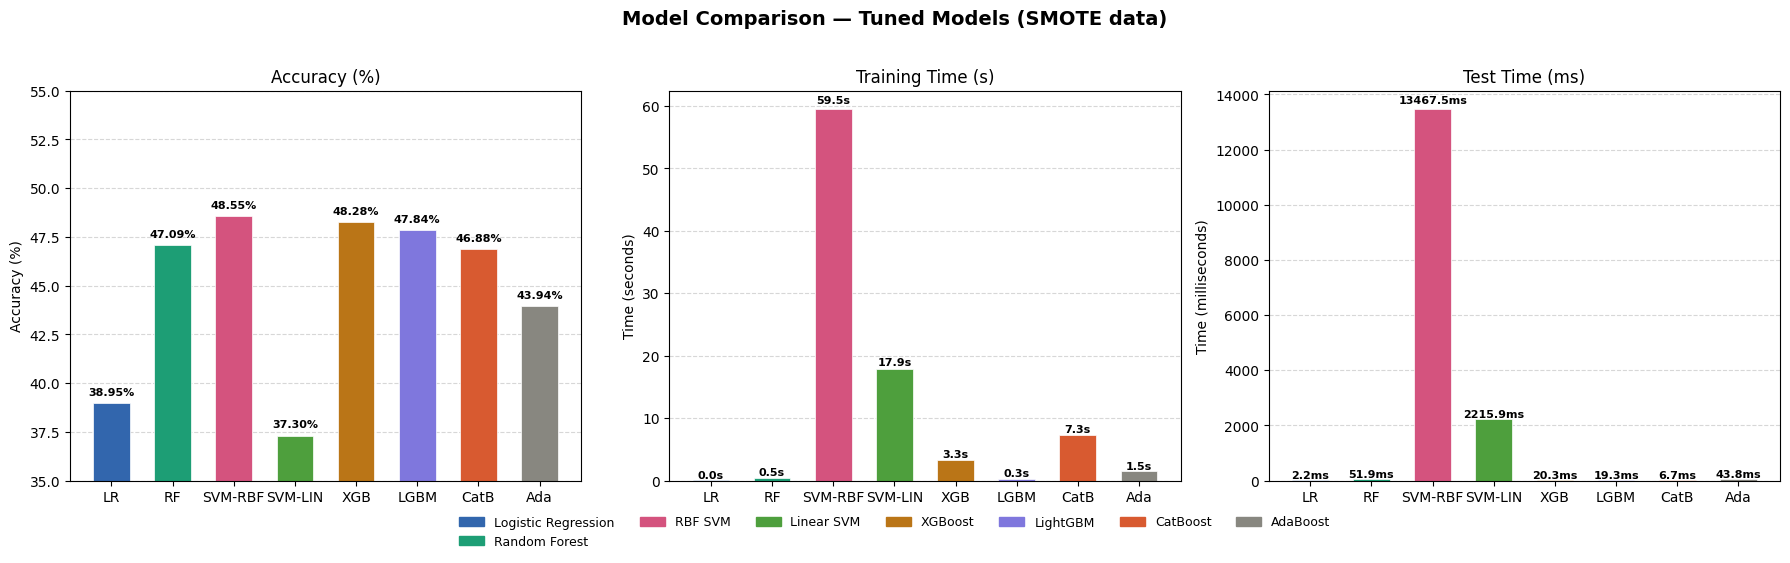


Plot saved as model_comparison.png


In [50]:
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Model list ───────────────────────────────────────────────────────────────
models_to_eval = [
    ("Logistic Regression", best_log),
    ("Random Forest",       best_rf),
    ("RBF SVM", best_svm_rbf),
    ("Linear SVM", best_svm_linear),
    ("XGBoost",             best_xgb),
    ("LightGBM",            best_lgbm),
    ("CatBoost",            best_cat),
    ("AdaBoost",            best_ada),
]

# ── Measure accuracy, training time, test time ───────────────────────────────
model_names   = []
accuracies    = []
train_times   = []
test_times    = []

for name, model in models_to_eval:
    # Training time
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    train_times.append(time.time() - t0)

    # Test / inference time
    t0 = time.time()
    y_pred = model.predict(X_test)
    test_times.append((time.time() - t0) * 1000)   # convert to ms

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc * 100)
    model_names.append(name)
    print(f"{name:25s} | acc={acc:.4f} | train={train_times[-1]:.2f}s | test={test_times[-1]:.1f}ms")

# ── Plot ─────────────────────────────────────────────────────────────────────
short_names = ["LR", "RF", "SVM-RBF", "SVM-LIN", "XGB", "LGBM", "CatB", "Ada"]
palette = [
    "#3266ad",
    "#1D9E75",
    "#D4537E",
    "#4E9F3D",
    "#BA7517",
    "#7F77DD",
    "#D85A30",
    "#888780"
]
x           = np.arange(len(model_names))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison — Tuned Models (SMOTE data)", fontsize=14, fontweight="bold", y=1.02)

# ── 1. Accuracy ──────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, accuracies, color=palette, edgecolor="white", linewidth=0.5, width=0.6)
ax.set_title("Accuracy (%)", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Accuracy (%)", fontsize=10)
ax.set_ylim(35, 55)
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── 2. Training time ─────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(x, train_times, color=palette, edgecolor="white", linewidth=0.5, width=0.6)
ax.set_title("Training Time (s)", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Time (seconds)", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
for bar, val in zip(bars, train_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{val:.1f}s", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── 3. Test time ─────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(x, test_times, color=palette, edgecolor="white", linewidth=0.5, width=0.6)
ax.set_title("Test Time (ms)", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Time (milliseconds)", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
for bar, val in zip(bars, test_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{val:.1f}ms", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── Legend ───────────────────────────────────────────────────────────────────
legend_patches = [mpatches.Patch(color=c, label=n) for c, n in zip(palette, model_names)]
fig.legend(handles=legend_patches, loc="lower center", ncol=7,
           bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as model_comparison.png")


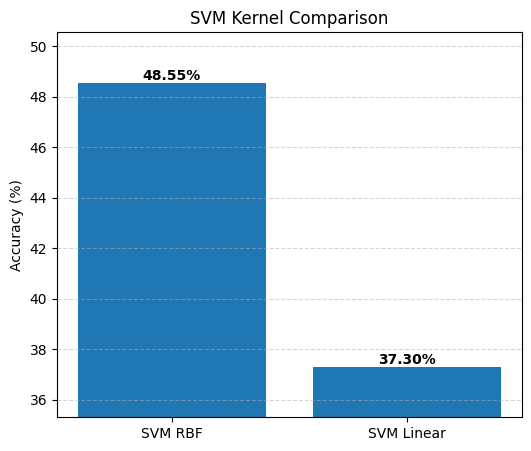


Plot saved as svm_kernel_comparison.png


In [51]:
# =========================================================
# SVM Kernel Comparison
# =========================================================

svm_names = ["SVM RBF", "SVM Linear"]

svm_accuracies = [
    accuracy_score(y_test, best_svm_rbf.predict(X_test)) * 100,
    accuracy_score(y_test, best_svm_linear.predict(X_test)) * 100
]

plt.figure(figsize=(6,5))

bars = plt.bar(svm_names, svm_accuracies)

plt.title("SVM Kernel Comparison")
plt.ylabel("Accuracy (%)")

plt.ylim(
    min(svm_accuracies) - 2,
    max(svm_accuracies) + 2
)

for bar, val in zip(bars, svm_accuracies):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{val:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig(
    "svm_kernel_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nPlot saved as svm_kernel_comparison.png")

In [52]:
# """## 1️⃣4️⃣ Save Models & Preprocessing Artifacts

# Paste this section at the END of your training notebook (after Section 13).
# Every object that was 'fit' or 'learned' during training is saved here,
# so the test script can reproduce the exact same preprocessing pipeline
# without re-training anything.
# """

# import pickle
# import os

# # ── Create folder ────────────────────────────────────────────────────────────
# os.makedirs("saved_pipeline_M2", exist_ok=True)


# with open("saved_pipeline_M2/cols_to_drop.pkl", "wb") as f:
#     pickle.dump(list(cols_to_drop), f)

# # ════════════════════════════════════════════════════════════════════
# # 1. IMPUTER
# # ════════════════════════════════════════════════════════════════════

# with open("saved_pipeline_M2/rf_imputer.pkl", "wb") as f:
#     pickle.dump(rf_imputer, f)

# # numerical columns
# with open("saved_pipeline_M2/numerical_cols.pkl", "wb") as f:
#     pickle.dump(list(numerical), f)

# # all numeric columns used later
# with open("saved_pipeline_M2/numeric_cols.pkl", "wb") as f:
#     pickle.dump(list(numeric_cols), f)


# # ════════════════════════════════════════════════════════════════════
# # 2. OUTLIER + LOG TRANSFORM ARTIFACTS
# # ════════════════════════════════════════════════════════════════════

# # IQR bounds for clipping
# with open("saved_pipeline_M2/iqr_bounds.pkl", "wb") as f:
#     pickle.dump(iqr_bounds, f)

# # columns that received log1p transform
# with open("saved_pipeline_M2/skewed_cols.pkl", "wb") as f:
#     pickle.dump(skewed_cols, f)


# # ════════════════════════════════════════════════════════════════════
# # 3. ENCODING ARTIFACTS
# # ════════════════════════════════════════════════════════════════════

# # 3a. Binary mapping
# binary_map = {
#     "Yes": 1,
#     "No": 0,
#     "True": 1,
#     "False": 0
# }

# with open("saved_pipeline_M2/binary_map.pkl", "wb") as f:
#     pickle.dump(binary_map, f)

# # 3b. Final columns after encoding
# with open("saved_pipeline_M2/ohe_columns.pkl", "wb") as f:
#     pickle.dump(list(X_train.columns), f)

# # 3c. Frequency encoding maps
# with open("saved_pipeline_M2/freq_maps.pkl", "wb") as f:
#     pickle.dump(freq_maps, f)

# with open("saved_pipeline_M2/mlb_encoders.pkl", "wb") as f:
#     pickle.dump(mlb_encoders, f)

# with open("saved_pipeline_M2/top_values_map.pkl", "wb") as f:
#     pickle.dump(top_values_map, f)


# # ════════════════════════════════════════════════════════════════════
# # 4. FEATURE SELECTION ARTIFACTS
# # ════════════════════════════════════════════════════════════════════


# # correlated columns removed
# with open("saved_pipeline_M2/corr_drop_cols.pkl", "wb") as f:
#     pickle.dump(list(to_drop_corr), f)

# # VarianceThreshold selector
# with open("saved_pipeline_M2/variance_selector.pkl", "wb") as f:
#     pickle.dump(selector, f)

# # columns used when fitting VarianceThreshold
# with open("saved_pipeline_M2/selector_input_cols.pkl", "wb") as f:
#     pickle.dump(list(X_before_variance.columns), f)

# # MI selected features
# with open("saved_pipeline_M2/mi_selected_features.pkl", "wb") as f:
#     pickle.dump(list(selected), f)

# # Final top features
# with open("saved_pipeline_M2/top_features.pkl", "wb") as f:
#     pickle.dump(list(top_features), f)


# # ════════════════════════════════════════════════════════════════════
# # 5. TRAINED MODELS
# # ════════════════════════════════════════════════════════════════════

# models_to_save = {
#     "best_random_forest":       best_rf,
#     "best_xgboost":             best_xgb,
#     "best_logistic_regression": best_log,
#     "best_svm_rbf":                 best_svm_rbf,
#     "best_svm_linear": best_svm_linear,
#     "best_lightgbm":            best_lgbm,
#     "best_catboost":            best_cat,
#     "best_adaboost":            best_ada,
# }

# for model_name, model_obj in models_to_save.items():

#     with open(f"saved_pipeline_M2/{model_name}.pkl", "wb") as f:
#         pickle.dump(model_obj, f)

#     print(f"Saved: {model_name}.pkl")


# # ════════════════════════════════════════════════════════════════════
# # 6. LABEL ENCODER
# # ════════════════════════════════════════════════════════════════════

# label_map = {0: "Low", 1: "Average", 2: "High"}
# with open("saved_pipeline_M2/label_map.pkl", "wb") as f:
#     pickle.dump(label_map, f)


# # ════════════════════════════════════════════════════════════════════
# # DONE
# # ════════════════════════════════════════════════════════════════════

# print("\n✅ All artifacts saved to 'saved_pipeline_M2/' folder.")

# print("\nFiles saved:")
# for fname in sorted(os.listdir("saved_pipeline_M2")):
#     print(f"  • {fname}")